In [9]:
from langgraph.graph import StateGraph,START,END# start and end are dummy node that signify the start and end of the graph
from langchain_ollama import ChatOllama
from typing import TypedDict


In [10]:
model=ChatOllama(model="llama3.1:8b")

In [6]:
# create state
class LLMState(TypedDict):
    input: str
    output: str

In [11]:
def LLM_qa(state=LLMState)->LLMState:
    question=state['input']
    prompt=f"Answer the following question {question}"
    answer=model.invoke(prompt)
    state['output']=answer
    return state

In [13]:
# create a graph
graph = StateGraph(LLMState)
graph.add_node("LLM_qa",LLM_qa)
#add edges
graph.add_edge(START,"LLM_qa")
graph.add_edge("LLM_qa",END)
workflow=graph.compile()


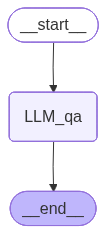

In [14]:
from IPython.display import Image# basically generates the graph image and displays it in the notebook
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
initial_state={"input":"What is the capital of France?"}
final_state=workflow.invoke(initial_state)

In [18]:
print(final_state['output'].content)

The capital of France is Paris.
